# Pure Reproduction: Heskes et al. (2020)

This notebook provides a **direct reproduction** of the main figures from:

> Heskes, T., Bucur, I. G., Sijben, E., & Claassen, T. (2020).  
> *Causal Shapley Values: Exploiting Causal Knowledge to Explain Individual Predictions of Complex Models*  
> NeurIPS 2020

We compute **pure Shapley values** (`index="SV"`, KernelSHAP) for the closest possible match to the R `shapr` package results.

### Methods
| Notation | R code | shapiq equivalent |
|----------|--------|-------------------|
| **MSV** (Marginal) | `approach="causal", ordering=list(c(1:7)), confounding=TRUE` | `MarginalImputer(sampling_method="gaussian")`, `index="SV"` |
| **CSV** (Causal) | `approach="causal", ordering=list(1,c(2,3),c(4:7)), confounding=c(F,T,F)` | `CausalImputer(sampling_method="gaussian")`, `index="SV"` |

### Remaining Differences from R
1. **XGBoost**: R vs Python produce slightly different models
2. **Random seed**: `set.seed(2020)` in R ≠ `default_rng(2020)` in Python
3. **Approximation**: shapiq KernelSHAP is regression-based; R enumerates all $2^7=128$ coalitions exactly

These produce **quantitative** but not **qualitative** differences.

### Reference
- Paper: https://arxiv.org/abs/2011.01625
- Original R code: https://gitlab.science.ru.nl/gbucur/caushapley
- Extended k-SII interaction analysis: see `heskes_paper_reproduction.ipynb`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

import shapiq
from shapiq import TabularExplainer
from shapiq.datasets import load_bike_sharing_daily, load_bike_sharing_daily_train_index

print(f"shapiq version: {shapiq.__version__}")

e:\Desktop\Shapley\Shapiq\shapiq\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shapiq version: None


## 1. Load Bike Sharing Daily Data

The paper uses the UCI Bike Sharing Dataset (daily aggregates) with 7 features:
- **trend**: Days since January 1, 2011
- **cosyear**: cos(2π × trend / 365) - cyclical season
- **sinyear**: sin(2π × trend / 365) - cyclical season
- **temp**: Unnormalized temperature (°C)
- **atemp**: Unnormalized feeling temperature (°C)
- **windspeed**: Unnormalized wind speed
- **hum**: Unnormalized humidity (%)

In [2]:
# Load preprocessed data from shapiq.datasets
x_data, y_data = load_bike_sharing_daily(preprocessed=True)
train_idx = load_bike_sharing_daily_train_index()

feature_names = ["trend", "cosyear", "sinyear", "temp", "atemp", "windspeed", "hum"]

# Create train/test split
all_idx = np.arange(len(x_data))
test_idx = np.array([i for i in all_idx if i not in train_idx])

print(f"Total samples: {len(x_data)} (CSV rows 2-732 in day.csv)")
print(f"Training samples: {len(train_idx)} (indices from train_index.npy)")
print(f"Test samples: {len(test_idx)}")
print(f"Features: {feature_names}")

Total samples: 731 (CSV rows 2-732 in day.csv)
Training samples: 587 (indices from train_index.npy)
Test samples: 144
Features: ['trend', 'cosyear', 'sinyear', 'temp', 'atemp', 'windspeed', 'hum']


In [3]:
# Prepare data with centering (as in original paper)
X_train = x_data.iloc[train_idx].values
y_train_nc = y_data.iloc[train_idx].values  # not centered
y_train_mean = y_train_nc.mean()
y_train = y_train_nc - y_train_mean  # centered

X_test = x_data.iloc[test_idx].values
y_test = y_data.iloc[test_idx].values - y_train_mean  # centered using train mean

print(f"y_train mean (φ₀): {y_train_mean:.2f}")

y_train mean (φ₀): 4505.03


## 2. Train XGBoost Model

In [4]:
model = xgb.XGBRegressor(
    n_estimators=100,
    random_state=1,
    verbosity=0
)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
print(f"Test RMSE (centered): {rmse:.2f}")

Test RMSE (centered): 775.24


## 3. Define Causal Structure

From Section 6 of the paper:
- **Layer 1 (Root cause)**: `{trend}`
- **Layer 2 (Confounded)**: `{cosyear, sinyear}` - season affects weather
- **Layer 3 (Mutual interactions)**: `{temp, atemp, windspeed, hum}`

Confounding:
- Layer 1: No confounding (singleton)
- Layer 2: **Confounding = True** (common cause breaks dependencies on intervention)
- Layer 3: No confounding (mutual interactions preserved)

> **Note**: An alternative causal ordering is available in `paper_figure3_alternative_ordering.ipynb`.

In [5]:
# Causal ordering (matching shapr R package)
ordering = [
    [0],           # Layer 1: trend (root)
    [1, 2],        # Layer 2: cosyear, sinyear (confounded)
    [3, 4, 5, 6],  # Layer 3: temp, atemp, windspeed, hum
]

# Confounding per component
confounding = [False, True, False]

print("Causal Structure:")
for i, layer in enumerate(ordering):
    layer_names = [feature_names[j] for j in layer]
    print(f"  Layer {i+1}: {layer_names} (confounding={confounding[i]})")

Causal Structure:
  Layer 1: ['trend'] (confounding=False)
  Layer 2: ['cosyear', 'sinyear'] (confounding=True)
  Layer 3: ['temp', 'atemp', 'windspeed', 'hum'] (confounding=False)


## 4. Create Explainers (Pure SV via KernelSHAP)

We create exactly **two** explainers matching the R code:

| Method | Description | `index` |
|--------|-------------|----------|
| **MSV** | Marginal (Gaussian) — all features independent | `"SV"` → KernelSHAP |
| **CSV** | Causal+Model (Gaussian) — respects causal ordering | `"SV"` → KernelSHAP |

Using `index="SV"` ensures we compute standard Shapley values $\varphi_i$ (not k-SII interaction indices).

In [6]:
# Configuration (matching R code: seed=2020, n_samples=500)
RANDOM_STATE = 2020
SAMPLE_SIZE = 500

explainers = {}

# MSV: Marginal (Gaussian) — matches R approach="causal", ordering=list(1:7), confounding=TRUE
explainers['MSV'] = TabularExplainer(
    model=model.predict,
    data=X_train,
    imputer="marginal",
    sampling_method="gaussian",
    sample_size=SAMPLE_SIZE,
    index="SV",
    random_state=RANDOM_STATE
)

# CSV: Causal+Model (Gaussian) — matches R approach="causal", partial ordering, confounding
explainers['CSV'] = TabularExplainer(
    model=model.predict,
    data=X_train,
    imputer="causal",
    ordering=ordering,
    confounding=confounding,
    sampling_method="gaussian",
    sample_size=SAMPLE_SIZE,
    index="SV",
    random_state=RANDOM_STATE
)

print("Explainers created:")
for name in explainers:
    print(f"  - {name}: index=SV (KernelSHAP)")

Explainers created:
  - MSV: index=SV (KernelSHAP)
  - CSV: index=SV (KernelSHAP)


E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\explainer\validation.py:93: UserWarning: Mismatch between max_order=2 and index=SV. Setting max_order=1. 
  validated_max_order = validate_max_order(validated_index, max_order)


## 5. Compute Shapley Values for All Test Samples

> **Note**: Expected runtime ~1 minutes (2 methods × all test samples).

In [7]:
budget = 2048
n_features = len(feature_names)

all_sv = {}

for exp_name, explainer in explainers.items():
    print(f"\nComputing SV (KernelSHAP) for {exp_name} across {len(X_test)} samples...")
    sv = np.zeros((len(X_test), n_features))
    
    for i in range(len(X_test)):
        result = explainer.explain(X_test[i:i+1], budget=budget)
        sv[i] = result.get_n_order_values(order=1)
        if (i + 1) % 50 == 0:
            print(f"  Processed {i + 1}/{len(X_test)}")
    
    all_sv[exp_name] = sv
    print(f"  Done!")

print("\n" + "="*60)
print("All Shapley values computed (pure SV via KernelSHAP).")
print("="*60)


Computing SV (KernelSHAP) for MSV across 144 samples...


E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is req

  Processed 50/144


E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is req

  Processed 100/144


...

  Processed 50/144


E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is req

  Processed 100/144


E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is req

  Done!

All Shapley values computed (pure SV via KernelSHAP).


## 6. Figure 3: Scatter Plots (2×2 Grid)

The original Figure 3 shows a 2×2 scatter plot grid:
- **Top left**: MSV temp (x) vs MSV cosyear (y)
- **Top right**: CSV cosyear (x) vs MSV cosyear (y)
- **Bottom left**: MSV temp (x) vs CSV temp (y)
- **Bottom right**: CSV cosyear (x) vs CSV temp (y)

All colored by temperature (blue=cold, red=hot).

![R Figure 3 top](scatter_plots_top_page-0001.jpg)
![R Figure 3 bottom](scatter_plots_bottom_page-0001.jpg)

C:\Users\bodun\AppData\Local\Temp\ipykernel_9632\2723422949.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 0.92])


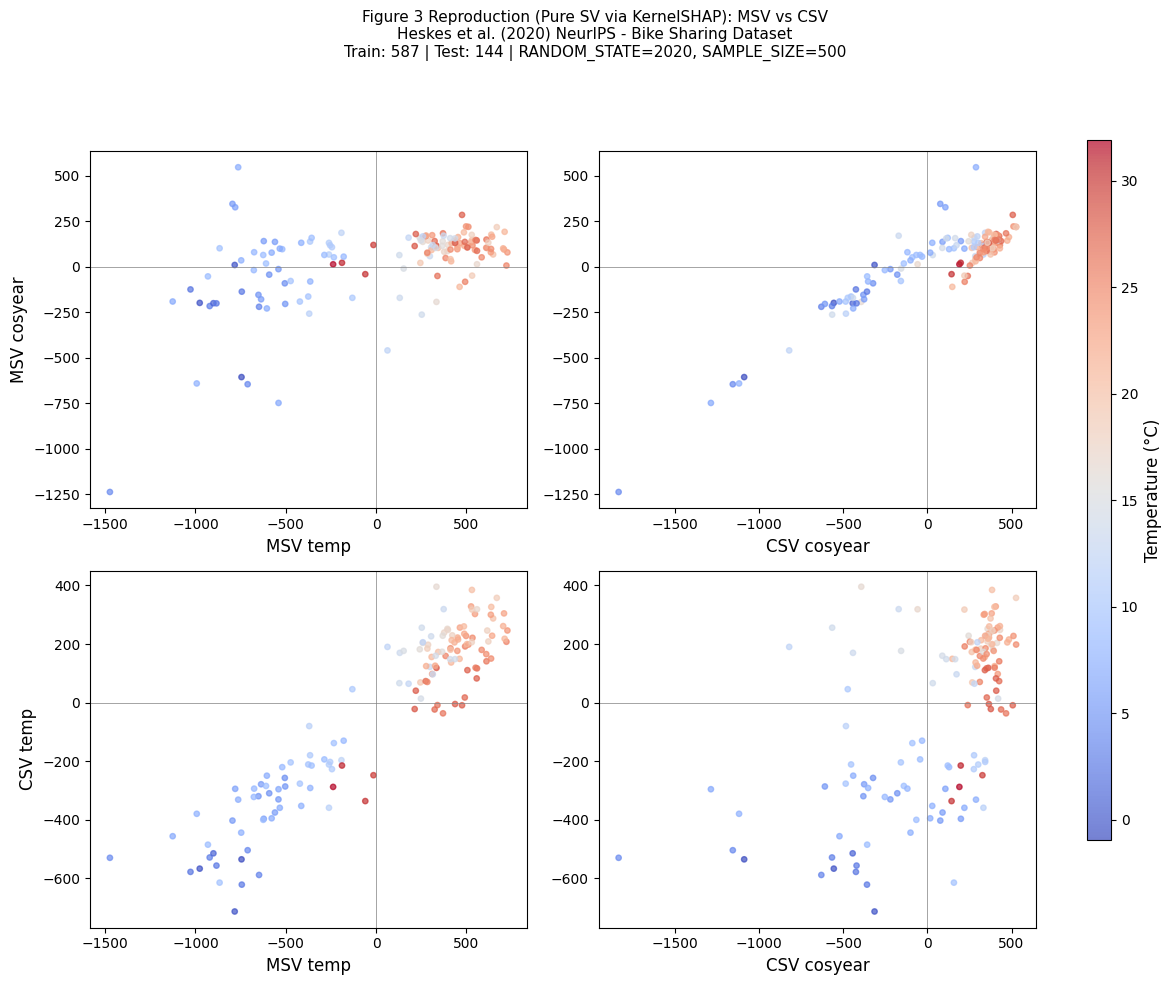

In [8]:
# Extract MSV and CSV Shapley values
sv_msv = all_sv['MSV']
sv_csv = all_sv['CSV']

temp_idx = feature_names.index('temp')
cosyear_idx = feature_names.index('cosyear')

sv_msv_temp = sv_msv[:, temp_idx]
sv_msv_cosyear = sv_msv[:, cosyear_idx]
sv_csv_temp = sv_csv[:, temp_idx]
sv_csv_cosyear = sv_csv[:, cosyear_idx]

# Temperature values for coloring
temp_values = X_test[:, temp_idx]

# Create 2x2 figure matching paper layout
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

cmap = 'coolwarm'
point_size = 15

# Top left: MSV temp (x) vs MSV cosyear (y)
ax = axes[0, 0]
scatter = ax.scatter(sv_msv_temp, sv_msv_cosyear, c=temp_values,
                    cmap=cmap, s=point_size, alpha=0.7)
ax.set_xlabel('MSV temp', fontsize=12)
ax.set_ylabel('MSV cosyear', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)

# Top right: CSV cosyear (x) vs MSV cosyear (y)
ax = axes[0, 1]
ax.scatter(sv_csv_cosyear, sv_msv_cosyear, c=temp_values,
          cmap=cmap, s=point_size, alpha=0.7)
ax.set_xlabel('CSV cosyear', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)

# Bottom left: MSV temp (x) vs CSV temp (y)
ax = axes[1, 0]
ax.scatter(sv_msv_temp, sv_csv_temp, c=temp_values,
          cmap=cmap, s=point_size, alpha=0.7)
ax.set_xlabel('MSV temp', fontsize=12)
ax.set_ylabel('CSV temp', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)

# Bottom right: CSV cosyear (x) vs CSV temp (y)
ax = axes[1, 1]
scatter = ax.scatter(sv_csv_cosyear, sv_csv_temp, c=temp_values,
                    cmap=cmap, s=point_size, alpha=0.7)
ax.set_xlabel('CSV cosyear', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)

# Add colorbar
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
cbar = fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label('Temperature (°C)', fontsize=12)

plt.suptitle('Figure 3 Reproduction (Pure SV via KernelSHAP): MSV vs CSV\n'
             'Heskes et al. (2020) NeurIPS - Bike Sharing Dataset\n'
             f'Train: {len(train_idx)} | Test: {len(test_idx)} | '
             f'RANDOM_STATE={RANDOM_STATE}, SAMPLE_SIZE={SAMPLE_SIZE}', fontsize=11)
plt.tight_layout(rect=[0, 0, 0.88, 0.92])
plt.show()

### Interpretation

The key insight from Figure 3:

**Marginal Shapley Values (MSV)**:
- `temp` shows strong positive/negative contributions
- `cosyear` shows weaker contributions
- Points form a linear pattern due to correlation between temp and season

**Causal Shapley Values (CSV)**:
- `cosyear` (season) absorbs much of the attribution that was on `temp`
- Season is a **root cause** of temperature in the causal graph
- When we intervene on season, temperature follows naturally
- CSV correctly attributes importance to the causal root (season)

## 7. Beeswarm: MSV vs CSV

Side-by-side beeswarm plots comparing feature attributions.

![R beeswarm](sina_plot_causal_page-0001.jpg)

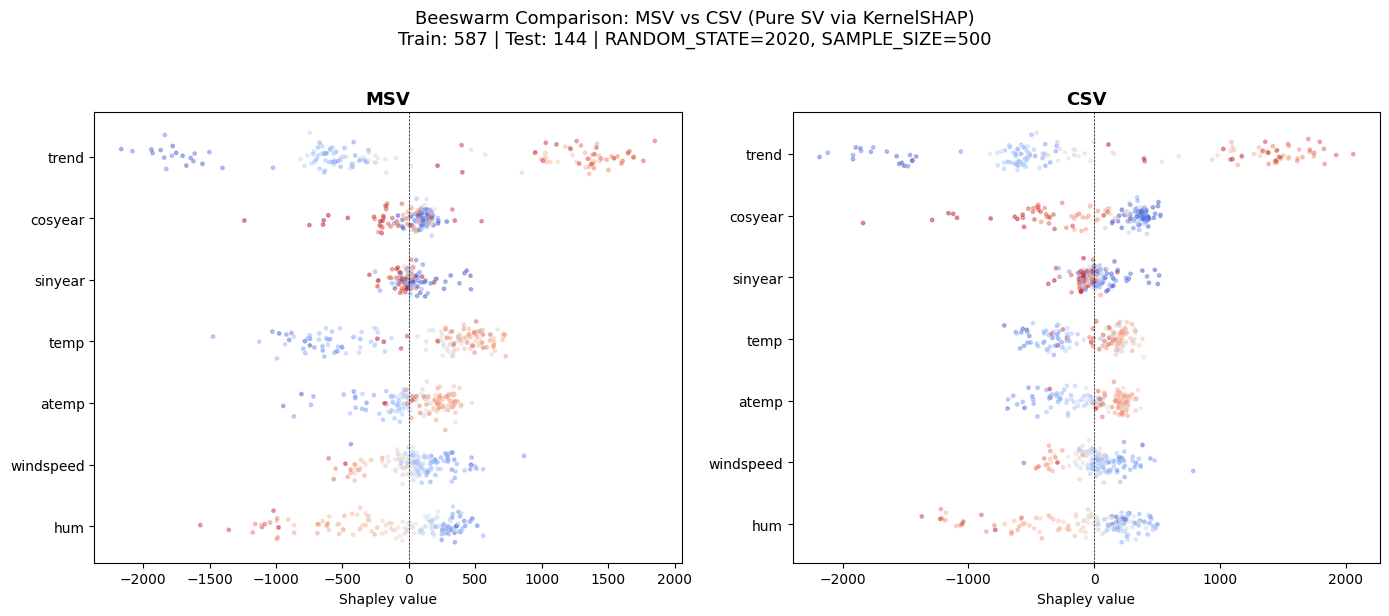

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# R uses fixed feature order (column order): trend, cosyear, sinyear, temp, atemp, windspeed, hum
# displayed top-to-bottom via factor(name, levels = rev(names(explanation$dt)))
order = list(range(len(feature_names)))  # 0,1,2,3,4,5,6 = fixed column order

for ax_idx, (exp_name, sv) in enumerate(all_sv.items()):
    ax = axes[ax_idx]
    
    for i, f_idx in enumerate(order):
        fv = X_test[:, f_idx]
        fv_norm = (fv - fv.min()) / (fv.max() - fv.min() + 1e-10)
        
        y_jitter = np.random.normal(0, 0.12, len(sv)) + (len(feature_names) - 1 - i)
        ax.scatter(sv[:, f_idx], y_jitter, c=fv_norm, cmap='coolwarm',
                  alpha=0.4, s=6)
    
    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels([feature_names[order[len(feature_names) - 1 - i]]
                        for i in range(len(feature_names))])
    ax.axvline(x=0, color='black', linewidth=0.5, linestyle='--')
    ax.set_xlabel('Shapley value')
    ax.set_title(exp_name, fontsize=13, fontweight='bold')

plt.suptitle('Beeswarm Comparison: MSV vs CSV (Pure SV via KernelSHAP)\n'
             f'Train: {len(train_idx)} | Test: {len(test_idx)} | '
             f'RANDOM_STATE={RANDOM_STATE}, SAMPLE_SIZE={SAMPLE_SIZE}',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. Two Similar Days (Figure 4)

Compare two days with similar temperatures but different seasons:
- **2012-10-09** (October): Temperature is expected for the season
- **2012-12-03** (December): Unusually warm for winter

CSV should attribute the December warmth more to `cosyear` (unusual season), while MSV treats both similarly.

![R Figure 4](bar_plots_page-0001.jpg)

October  2012-10-09 (idx 647): temp=13.0°C, cosyear=0.14
December 2012-12-03 (idx 702): temp=13.3°C, cosyear=0.89


E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)


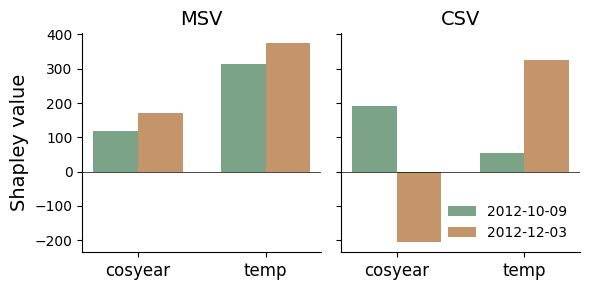


TWO SIMILAR DAYS: SHAPLEY VALUE COMPARISON
Method      Oct cosyear  Dec cosyear   Oct temp   Dec temp
----------------------------------------------------------------------
MSV              118.27       170.03     313.90     374.12
CSV              192.19      -206.15      52.88     324.78

Key: CSV should show higher |cosyear| for December (unusual warmth for season).


In [13]:
# Two Similar Days: matching R code date-based selection
# R: october <- which(bike$dteday == "2012-10-09")
# R: december <- which(bike$dteday == "2012-12-03")
# In day.csv: instant 648 = 2012-10-09, instant 703 = 2012-12-03

from shapiq.datasets import load_bike_sharing_daily
x_full, y_full = load_bike_sharing_daily(preprocessed=True)

october_idx = 647   # 2012-10-09 (instant=648)
december_idx = 702  # 2012-12-03 (instant=703)

oct_temp = x_full.loc[october_idx, 'temp']
oct_cosyear = x_full.loc[october_idx, 'cosyear']
dec_temp = x_full.loc[december_idx, 'temp']
dec_cosyear = x_full.loc[december_idx, 'cosyear']

print(f"October  2012-10-09 (idx {october_idx}): temp={oct_temp:.1f}°C, cosyear={oct_cosyear:.2f}")
print(f"December 2012-12-03 (idx {december_idx}): temp={dec_temp:.1f}°C, cosyear={dec_cosyear:.2f}")

# Compute Shapley values for these two days
days_x = x_full.loc[[october_idx, december_idx], feature_names].values

sv_days = {}
for exp_name, explainer in explainers.items():
    sv_list = []
    for x in days_x:
        result = explainer.explain(x.reshape(1, -1), budget=budget)
        sv_list.append(result.get_n_order_values(order=1))
    sv_days[exp_name] = np.array(sv_list)

# -------------------------------------------------------------------
# Figure 4 layout matching R: facet_wrap(vars(type))
#   - One panel per method (MSV, CSV)
#   - X-axis: feature names (cosyear, temp)
#   - Grouped bars: October vs December (position="dodge")
# -------------------------------------------------------------------
method_names = list(explainers.keys())
feat_labels = ['cosyear', 'temp']
feat_indices = [cosyear_idx, temp_idx]
date_labels = ['2012-10-09', '2012-12-03']
date_colors = ['#7BA388', '#C4956A']   # sage, terracotta

fig, axes = plt.subplots(1, len(method_names), figsize=(6, 3), sharey=True)
if len(method_names) == 1:
    axes = [axes]

bar_width = 0.35
x_pos = np.arange(len(feat_labels))

for ax_idx, m_name in enumerate(method_names):
    ax = axes[ax_idx]
    oct_vals = [sv_days[m_name][0, fi] for fi in feat_indices]
    dec_vals = [sv_days[m_name][1, fi] for fi in feat_indices]

    bars_oct = ax.bar(x_pos - bar_width / 2, oct_vals, bar_width,
                      color=date_colors[0], label=date_labels[0])
    bars_dec = ax.bar(x_pos + bar_width / 2, dec_vals, bar_width,
                      color=date_colors[1], label=date_labels[1])

    ax.set_xticks(x_pos)
    ax.set_xticklabels(feat_labels, fontsize=12)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_title(m_name, fontsize=14)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if ax_idx == 0:
        ax.set_ylabel('Shapley value', fontsize=14)

# Legend inside last panel (matching R: legend.position = c(0.75, 0.25))
axes[-1].legend(loc='lower right', fontsize=10, frameon=False)

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*70)
print("TWO SIMILAR DAYS: SHAPLEY VALUE COMPARISON")
print("="*70)
print(f"{'Method':<10} {'Oct cosyear':>12} {'Dec cosyear':>12} {'Oct temp':>10} {'Dec temp':>10}")
print("-"*70)
for m in method_names:
    sv = sv_days[m]
    print(f"{m:<10} {sv[0, cosyear_idx]:>12.2f} {sv[1, cosyear_idx]:>12.2f} "
          f"{sv[0, temp_idx]:>10.2f} {sv[1, temp_idx]:>10.2f}")
print("\nKey: CSV should show higher |cosyear| for December (unusual warmth for season).")

## Summary

This notebook reproduced the main figures from Heskes et al. (2020) using `shapiq` with `index="SV"` (KernelSHAP), providing the closest possible match to the R `shapr` package.

**Key qualitative conclusions** (matching the paper):
1. **MSV** attributes importance largely to `temp` (direct predictor)
2. **CSV** shifts attribution to `cosyear` (the causal root cause of temperature)
3. For the two similar days, **CSV** correctly identifies that December's warm weather is unusual for the season

For extended analysis including k-SII interaction indices, copula sampling, and model-free causal estimation, see `heskes_paper_reproduction.ipynb`.